# CDD API - Conversational Diagram Designer

This notebook demonstrates the CDD system end-to-end. It is the canonical
API tutorial that follows GP's `template.API.ipynb` pattern.

**Pipeline:** natural language → LLM → diagram code → renderer → image
→ (optional) multimodal vision critique → corrected code → re-render → loop
(cap: 3 iterations).

**Supports:** Graphviz DOT, Mermaid, PlantUML.

**How to run:**
1. `./docker_build.sh`
2. `./docker_jupyter.sh`
3. Open this notebook and run all cells

Or launch the React UI: `./docker_app.sh` → http://localhost:8000

## 1. Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import cdd_config as config
import cdd_llm as llm
import cdd_renderer as renderer
from cdd_orchestrator import CDDOrchestrator
from IPython.display import Image, SVG, display

print(f"Default LLM provider: {config.LLM_PROVIDER}")
print(f"Supported formats: {config.SUPPORTED_FORMATS}")
print(f"Vision feedback enabled by default: {config.VISION_FEEDBACK_ENABLED}")
print(f"Vision iteration cap: {config.VISION_MAX_ITERATIONS}")

Default LLM provider: gemini
Supported formats: ['graphviz', 'mermaid', 'plantuml']
Vision feedback enabled by default: True
Vision iteration cap: 3


## 2. Single-shot generation: Graphviz

Generate a Graphviz DOT diagram from a natural language description.
This is the simplest CDD interaction.

In [2]:
orch = CDDOrchestrator(format="graphviz")
prompt_1 = (
    "Draw a flowchart for user login: start, enter credentials, validate, "
    "if valid go to dashboard, if invalid show error and retry, "
    "max 3 retries then lock account"
)
diagram_source, image_bytes = orch.process_message(prompt_1)
print("Generated DOT source:")
print(diagram_source)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Generated DOT source:
digraph UserLoginFlowchart {
    graph [
        label="User Login Flow",
        labelloc="t",
        fontname="Helvetica",
        fontsize=18
    ];
    node [
        fontname="Helvetica",
        fontsize=12,
        style=filled,
        fillcolor=white,
        color=black
    ];
    edge [
        fontname="Helvetica",
        fontsize=10
    ];

    // Nodes
    start [label="Start", shape=oval, fillcolor=lightgreen];
    enter_creds [label="Enter Credentials", shape=box];
    validate [label="Validate Credentials", shape=box];
    is_valid [label="Credentials Valid?", shape=diamond, fillcolor=lightblue];
    dashboard [label="Go to Dashboard", shape=box, fillcolor=palegreen];
    show_error [label="Show Error Message", shape=box, fillcolor=salmon];
    retry_count [label="Retry Count < 3?", shape=diamond, fillcolor=lightblue];
    lock_account [label="Lock Account", shape=box, fillcolor=red];
    end [label="End", shape=oval, fillcolor=lightgreen];

   

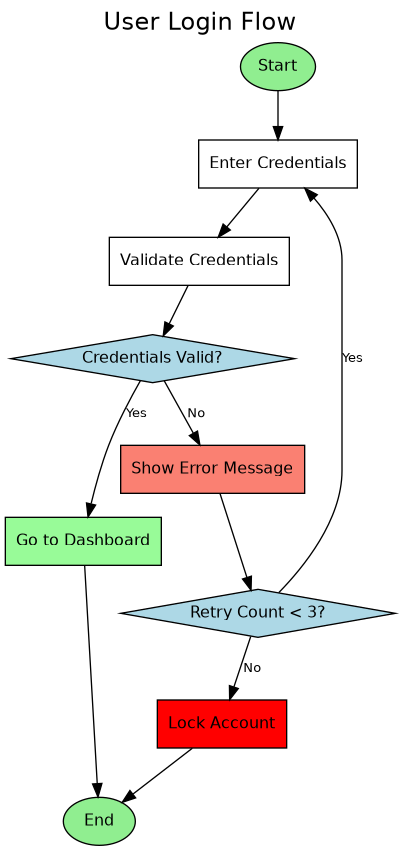

Iterations used: 5


In [3]:
display(Image(data=image_bytes))
print(f"Iterations used: {len(orch.state.last_trace)}")

## 3. Multi-turn refinement

CDD keeps conversation history and modifies the existing diagram in place.

Revision: 2


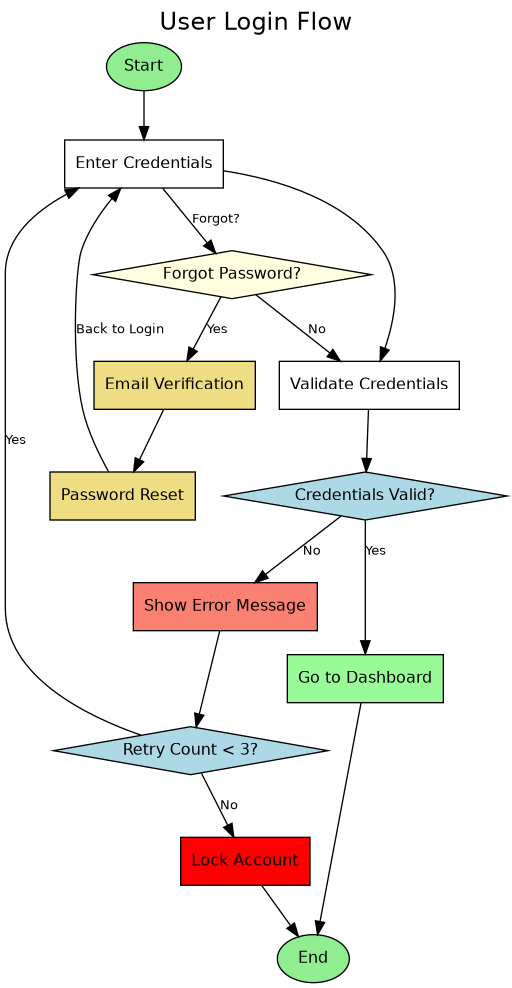

In [4]:
_, img2 = orch.process_message(
    "Add a 'Forgot Password' branch from login to email verification, "
    "then password reset, then back to login"
)
print(f"Revision: {orch.state.revision_count}")
display(Image(data=img2))

Revision: 3


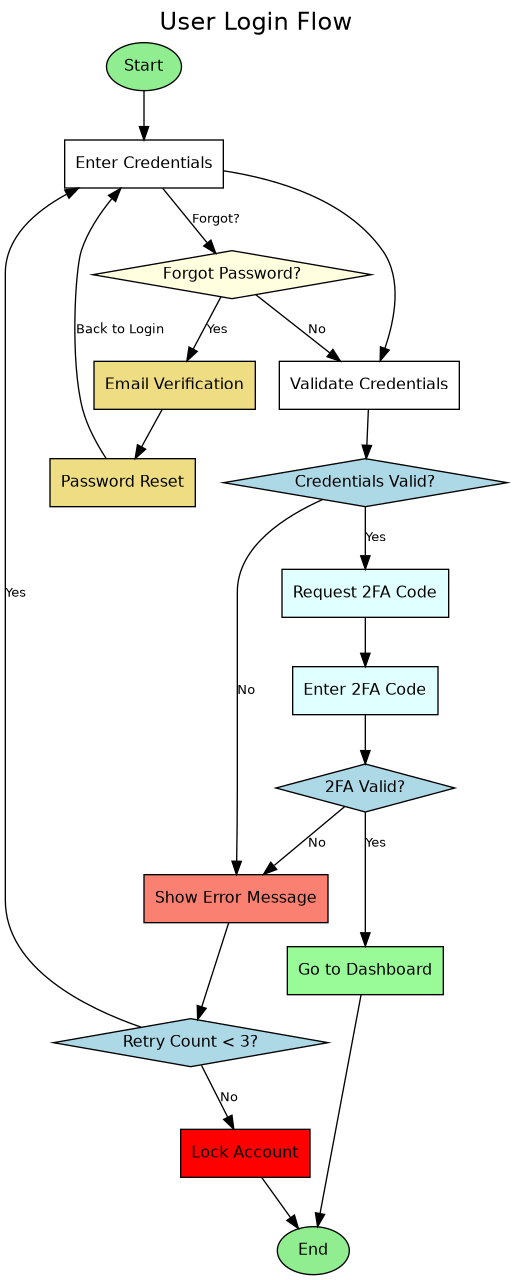

In [6]:
_, img3 = orch.process_message(
    "Add two-factor authentication after credential validation, before dashboard"
)
print(f"Revision: {orch.state.revision_count}")
display(Image(data=img3))

## 4. Mermaid format

Switching format means a new orchestrator (or reset). Here we generate a
Mermaid sequence diagram. Mermaid renders via the public Kroki server, so
this requires network access from the container.

Generated Mermaid source:
sequenceDiagram
    participant User
    participant Browser
    participant Server
    participant Database

    User->>Browser: Clicks Login
    activate Browser
    Browser->>Server: Sends Credentials
    activate Server
    Server->>Database: Validate Credentials
    activate Database
    Database-->>Server: Validation Result
    deactivate Database
    Server-->>Browser: Returns Session Token
    deactivate Server
    Browser->>Browser: Stores Session Token
    Browser->>User: Redirects
    deactivate Browser


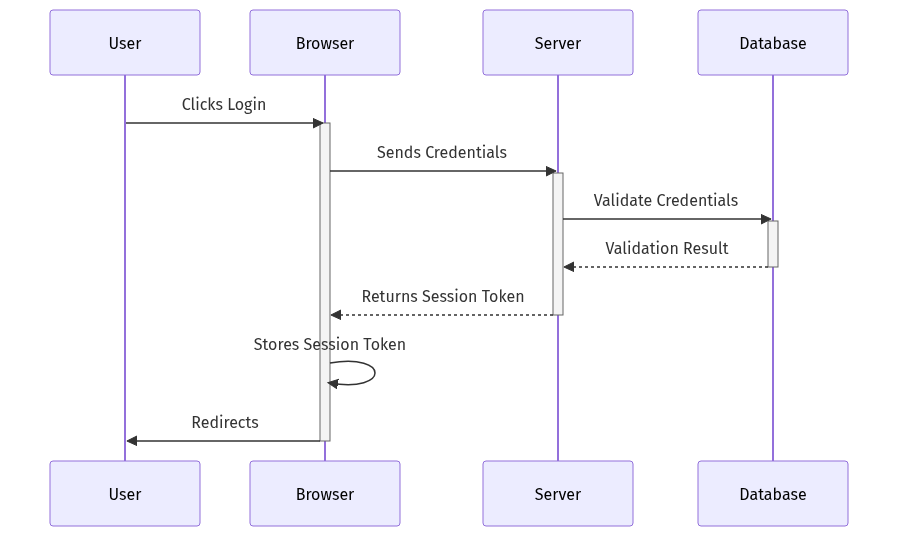

In [7]:
orch_m = CDDOrchestrator(format="mermaid")
mermaid_prompt = (
    "Create a sequence diagram: A user clicks login. The browser sends "
    "credentials to the server. The server validates against the database "
    "and returns a session token. The browser stores it and redirects."
)
src_m, img_m = orch_m.process_message(mermaid_prompt)
print("Generated Mermaid source:")
print(src_m)
display(Image(data=img_m))

## 5. PlantUML format

PlantUML is rendered via the public PlantUML server (also network-dependent).

In [8]:
orch_p = CDDOrchestrator(format="plantuml")
plantuml_prompt = (
    "Class diagram: Animal (name, age), Dog extends Animal (breed), "
    "Cat extends Animal (indoor). Kennel has many Dogs."
)
src_p, img_p = orch_p.process_message(plantuml_prompt)
print("Generated PlantUML source:")
print(src_p)
display(Image(data=img_p))

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 32.263605248s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-flash'},

## 6. Vision feedback loop in action

This is the centerpiece feature. With vision feedback enabled (the default),
CDD renders the diagram, sends the image to a multimodal model, gets a
critique, and iterates if the critique flags issues. Capped at 3 iterations.

The trace recorded in `orch.state.last_trace` shows every step.

In [ ]:
orch_v = CDDOrchestrator(format="graphviz", vision_feedback=True)
_, _ = orch_v.process_message(
    "Microservices architecture: API Gateway routes to three services "
    "(catalog, orders, payments). All three services share a Redis cache "
    "and a PostgreSQL database. Show clear hierarchy."
)
print("Trace from this turn (each entry is one pipeline step):")
for step in orch_v.state.last_trace:
    print(f"  {step}")

## 7. Vision feedback OFF (single-shot baseline)

For comparison: the same prompt with vision feedback disabled. This is
the baseline we use in the evaluation study (`cdd.example.ipynb`).

In [ ]:
orch_baseline = CDDOrchestrator(format="graphviz", vision_feedback=False)
_, _ = orch_baseline.process_message(
    "Microservices architecture: API Gateway routes to three services "
    "(catalog, orders, payments). All three services share a Redis cache "
    "and a PostgreSQL database. Show clear hierarchy."
)
print("Trace (vision off — should show only one iteration):")
for step in orch_baseline.state.last_trace:
    print(f"  {step}")

## 8. Different diagram types

In [ ]:
orch_class = CDDOrchestrator(format="graphviz")
_, img_c = orch_class.process_message(
    "Create a class diagram: Book (title, isbn, price), Author (name, bio), "
    "Customer (name, email), Order (date, total). Author writes many Books. "
    "Customer places many Orders. Order contains many Books."
)
display(Image(data=img_c))

In [ ]:
orch_sm = CDDOrchestrator(format="graphviz")
_, img_s = orch_sm.process_message(
    "State machine for an order: Draft -> Submitted -> Under Review -> "
    "Approved or Rejected. Approved -> Fulfilled -> Closed. Rejected -> Draft."
)
display(Image(data=img_s))

## 9. Export

In [ ]:
orch.export_dot("/tmp/login_flow.dot")
orch.export_image("/tmp/login_flow.png", fmt="png")
orch.export_image("/tmp/login_flow.svg", fmt="svg")
print("Exported DOT, PNG, SVG to /tmp/")

## 10. Validation

The renderer validates source before rendering, so syntax errors are
caught early and surface a clear error.

Bad DOT — Valid: True, Error: 
Good DOT — Valid: True


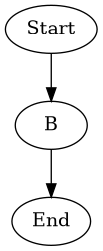

In [9]:
bad_dot = "digraph { this is invalid }"
is_valid, error = renderer.validate(bad_dot, "graphviz")
print(f"Bad DOT — Valid: {is_valid}, Error: {error[:80]}")

good_dot = 'digraph { A -> B -> C; A [label="Start"]; C [label="End"]; }'
is_valid, _ = renderer.validate(good_dot, "graphviz")
print(f"Good DOT — Valid: {is_valid}")
display(Image(data=renderer.render(good_dot, "graphviz")))

## 11. State inspection

In [10]:
import json

state = orch.get_state_dict()
print(f"Format: {state['format']}")
print(f"Revisions: {state['revision_count']}")
print(f"Conversation turns: {len(state['conversation_history']) // 2}")
print(f"Last trace step count: {len(state['last_trace'])}")

Format: graphviz
Revisions: 3
Conversation turns: 3
Last trace step count: 5
